In [ ]:
### Load libraries and set params
library(Matrix)
library(parallel)
library(Seurat)
library(gridExtra)
library(ggplot2)
library(future)
library(ggpubr)
library(viridis)
library(openxlsx)
library(viridis)
library(scran)
library(gghighlight)
library(dplyr)
library(org.Dm.eg.db)
library(ggExtra)
library(scDblFinder)
library(patchwork)
library(RhpcBLASctl)
blas_set_num_threads(18)
library(peakRAM)
options(device=pdf)
options(future.globals.maxSize = 214748364800)
library(future)
plan("multicore", workers = 18)

### Set directories
mainDir <- "/data/ebaird/scRNAseq/2025_2026_int/"
repDir <- paste0(mainDir, "subset_reanalysis/", format(Sys.time(), "%Y%m%d_%H%M%S"), "/")
figDir <- paste0(repDir, "figs/")
tabDir <- paste0(repDir, "tables/")
refsDir <- paste0(mainDir, "refs/")


dir.create(repDir, recursive = TRUE, showWarnings = FALSE)
dir.create(figDir, recursive = TRUE, showWarnings = FALSE)
dir.create(tabDir, recursive = TRUE, showWarnings = FALSE)

### Set colours
mycols <- c(1, '#ffffe5','#fff7bc','#fee391','#fec44f','#fe9929','#ec7014','#cc4c02','#993404','#662506')
mycols11 <- c(1, '#fee391','#fec44f','#fe9929','#ec7014','#cc4c02','#993404','#662506', "purple", "violet", "gray")
mycols13 <- c(1, '#fee391','#fec44f','#fe9929','#ec7014','#cc4c02','#993404','#662506', "purple", "violet", "gray", "blue", "green")
mycols17 <- c(1, '#fee391','#fec44f','#fe9929','#ec7014','#cc4c02','#993404','#662506', "purple", "violet", "gray", "blue", "green", rainbow(4))

mycols20 <- c("yellow", '#fee391','#fec44f','#fe9929','#ec7014','#cc4c02','#993404','#662506', "purple", "violet", "chartreuse", "blue", "green", rainbow(4), "darkslategray3", "darksalmon", "darkorchid4", "cyan")

corner <- function(x) x[1:5,1:5]
cols <- c(colorRamps::matlab.like2(20)[1:18], "deeppink2", "deeppink3", "deeppink4")

getdensity <- function(x, y, ...) {
      dens <- MASS::kde2d(x, y, ...)
      ix <- findInterval(x, dens$x)
      iy <- findInterval(y, dens$y)
      ii <- cbind(ix, iy)
      return(dens$z[ii])
}

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘ggpubr’ was built under R version 4.4.3”
Loading required package: viridisLite

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, col

In [15]:
# Load object
seu <- readRDS(file = paste0(mainDir, "/QC_clustering/integrated.rds"))

In [ ]:
DimPlot(seu, group.by = "seurat_clusters", reduction = "umap")

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Will not return corrected UMI because residual type is not set to 'pearson'

Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“Different cells and/or features from existing assay SCT”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used

pdf 
  2

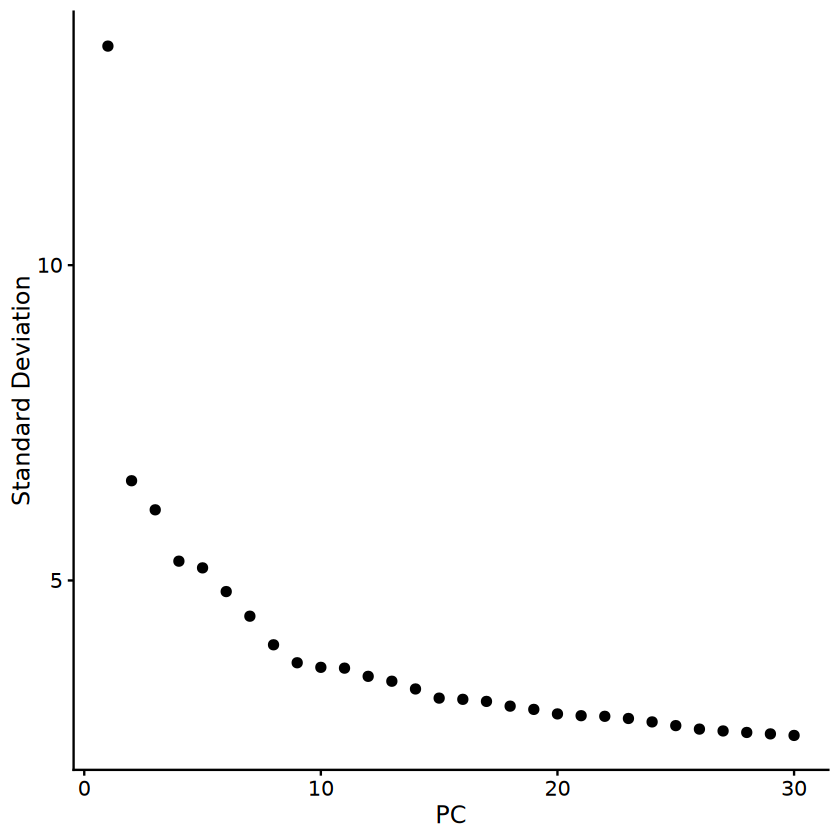

In [4]:
### Cluster subsetting
Idents(seu) <- seu$seurat_clusters

# Subsets
subsets <- list(
    neuronal_progenitor = c("3", "7", "2", "11")
)

subset_name <- "neuronal_progenitor"

subset <- subset(seu, idents = subsets[[subset_name]])
subset <- SCTransform(subset, verbose = FALSE, return.only.var.genes = FALSE, conserve.memory = TRUE, vst.flavor = "v1")
subset <- RunPCA(subset, npcs = 30, verbose = FALSE)

subset$original_clusters <- subset$seurat_clusters

pdf(paste0(figDir, "elbow_", subset_name, "subset.pdf"))
ElbowPlot(subset, ndims=30)
dev.off()
ElbowPlot(subset, ndims=30)

In [6]:
# Plot UMAP at varying dimensions, fixed resolution at 1.0
dims_range <- 5:25
plots_dims <- list()

for (d in dims_range) {

  seu_tmp <- subset
  
  seu_tmp <- RunUMAP(seu_tmp, dims = 1:d, verbose = FALSE)
  seu_tmp <- FindNeighbors(seu_tmp, dims = 1:d, verbose = FALSE)
  seu_tmp <- FindClusters(seu_tmp, resolution = 1.0, verbose = FALSE)

  p <- DimPlot(
        seu_tmp,
        group.by = "SCT_snn_res.1",
        reduction = "umap",
        label = TRUE
      ) +
      ggtitle(paste0("dims = ", d, ", res = 1.0"))

  plots_dims[[length(plots_dims) + 1]] <- p
}

jpeg_file <- paste0(figDir, "UMAP_dims_sweep.jpeg")

jpeg(filename = jpeg_file, width = 4000, height = 4000, res = 200)

gridExtra::grid.arrange(
  grobs = plots_dims,
  ncol = 4
)

dev.off()

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_lapply-1’ (2a0f81a1cfb772ac2b5e36980b2c50b3-113); on 2a0f81a1cfb772ac2b5e36980b2c50b3@node1<3284372>]”
Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a pa

pdf 
  2

In [ ]:
# Plot UMAP at fixed dimensions, varying resolutions
dims_use <- 16
resolutions <- seq(0.4, 1.6, by = 0.1)

seu_tmp <- subset
seu_tmp <- RunUMAP(seu_tmp, dims = 1:dims_use, verbose = FALSE)
seu_tmp <- FindNeighbors(seu_tmp, dims = 1:dims_use, verbose = FALSE)

seu_tmp <- FindClusters(
  seu_tmp,
  resolution = resolutions,
  verbose = FALSE
)

plots_res <- lapply(resolutions, function(r) {

  colname <- paste0("SCT_snn_res.", r)

  DimPlot(
    seu_tmp,
    group.by = colname,
    reduction = "umap",
    label = TRUE
  ) +
  ggtitle(paste0("dims = ", dims_use, ", res = ", r))

})

jpeg_file <- paste0(figDir, "UMAP_resolution_sweep.jpeg")

jpeg(filename = jpeg_file, width = 4000, height = 3000, res = 200)

gridExtra::grid.arrange(
  grobs = plots_res,
  ncol = 4
)

dev.off()

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_lapply-1’ (2a0f81a1cfb772ac2b5e36980b2c50b3-530); on 2a0f81a1cfb772ac2b5e36980b2c50b3@node1<3284372>]”
Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-2’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a pa

pdf 
  2

In [17]:
### Recompute final UMAP and resolution
subset <- RunUMAP(subset, dims = 1:16)
subset <- FindNeighbors(subset, dims = 1:16, verbose = FALSE)
subset <- FindClusters(subset, verbose = FALSE, resolution=0.6)

20:46:16 UMAP embedding parameters a = 0.9922 b = 1.112

20:46:16 Read 12823 rows and found 16 numeric columns

20:46:16 Using Annoy for neighbor search, n_neighbors = 30

20:46:16 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*


*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

20:46:17 Writing NN index file to temp file /tmp/RtmpfH2m6h/file321d941f40b0c6

20:46:17 Searching Annoy index using 18 threads, search_k = 3000

20:46:18 Annoy recall = 100%

20:46:19 Commencing smooth kNN distance calibration using 18 threads
 with target n_neighbors = 30

20:46:21 Initializing from normalized Laplacian + noise (using RSpectra)

20:46:21 Commencing optimization for 200 epochs, with 531018 positive edges

20:46:21 Using rng type: pcg

20:46:28 Optimization finished

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this

pdf 
  2

pdf 
  2

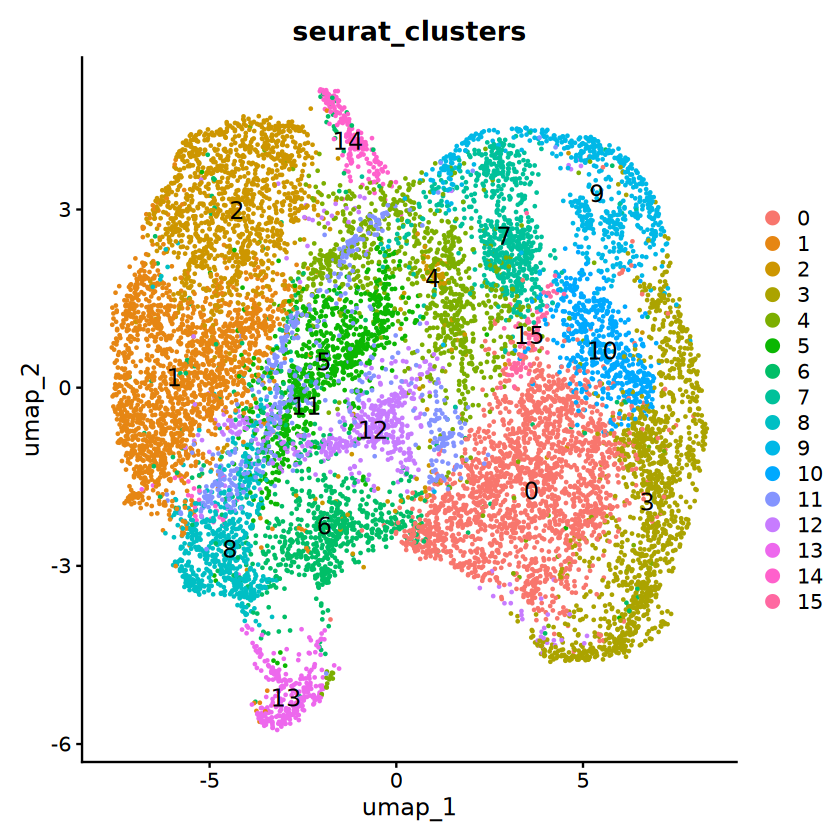

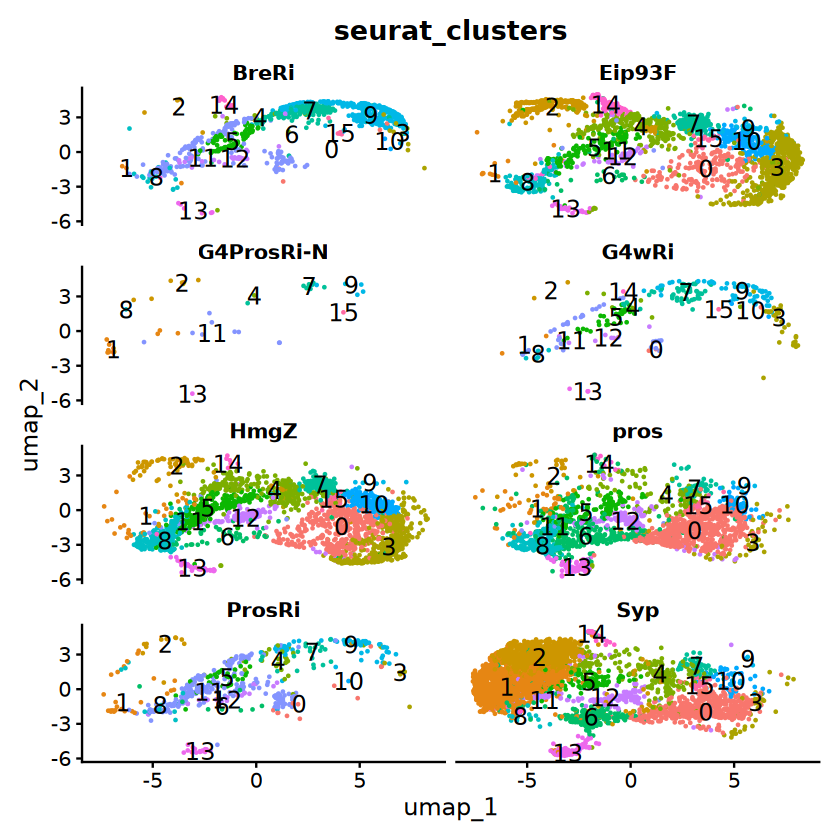

In [ ]:
### Save UMAP
jpeg(paste0(figDir, "UMAP.neuronal_progenitors.jpeg"), width = 900, height = 900, res = 150)
DimPlot(subset, reduction = "umap", group.by = "seurat_clusters", label = TRUE, label.size = 5) +
  theme(legend.position = "none")
dev.off()
DimPlot(subset, reduction = "umap", group.by = "seurat_clusters", label = TRUE, label.size = 5)

jpeg(paste0(figDir, "UMAP.neuronal_progenitors_split.jpeg"), width = 1800, height = 3600, res = 150)
DimPlot(subset, reduction = "umap", group.by = "seurat_clusters", label = TRUE, label.size = 5, split.by = "sample", ncol = 2) +
  theme(legend.position = "none")
dev.off()
DimPlot(subset, reduction = "umap", group.by = "seurat_clusters", label = TRUE, label.size = 5, split.by = "sample", ncol = 2) +
  theme(legend.position = "none")

In [12]:
saveRDS(subset, file = paste0(repDir, subset_name, "_subset.rds"))
# subset <- readRDS(paste0(repDir, "panagiotis_subset.rds"))

In [13]:
# Trace origin of cells in each cluster of the subset
for (i in levels(Idents(subset))) {
  cells <- WhichCells(subset, idents = i)
  cat("Cluster", i, ":", length(cells), "cells\n")
  
  original_clusters <- seu@meta.data[cells, "seurat_clusters"]
  
  print(table(original_clusters))
}

Cluster 2 : 4400 cells
original_clusters
  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15 
 67 526 992   2 252 773 562  32 398  13   7 279 118 210 164   5 
Cluster 3 : 3869 cells
original_clusters
   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
1654    5   18 1254   67    4   35   20    3  308  355   73   31    5    0   37 
Cluster 7 : 2683 cells
original_clusters
  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15 
212   0 269  38 592  22  38 632   1 237 179  70 320   4  29  40 
Cluster 11 : 1871 cells
original_clusters
   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
   2 1177   34    0    0    9  160    1  235    5    0  101   41   81   25    0 


pdf 
  2

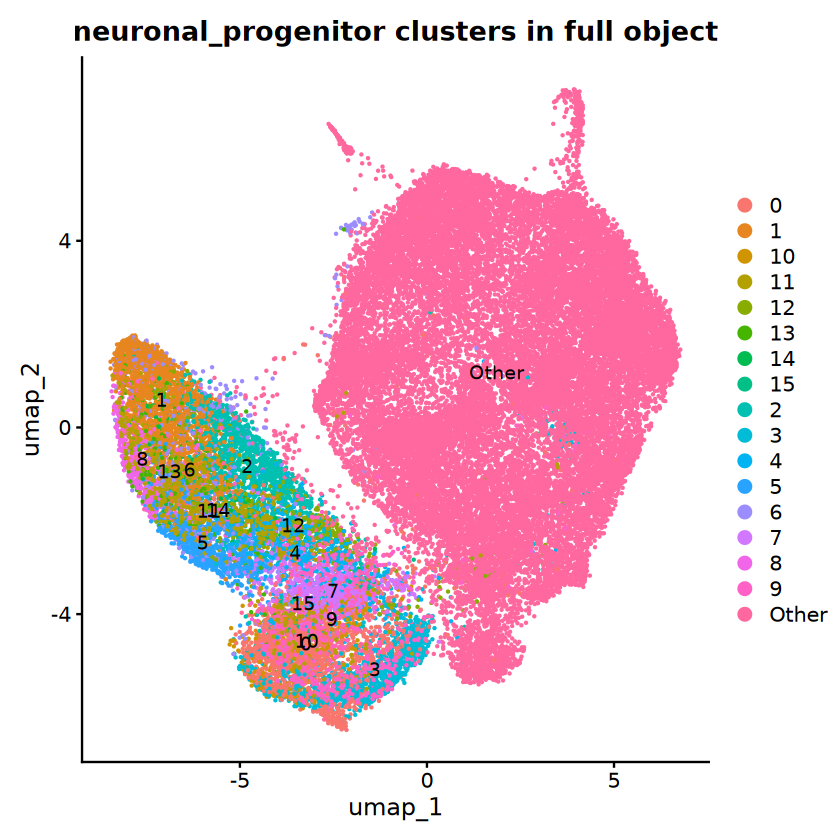

In [18]:
### Add new clustering as metadata to full seurat object
new_idents <- Idents(subset)

vector <- rep("Other", length(Cells(seu)))
names(vector) <- Cells(seu)

vector[names(new_idents)] <- as.character(new_idents)

cluster_assignment <- paste0(subset_name,"_clusters")
seu[[cluster_assignment]] <- vector

DimPlot(seu, group.by = paste0(subset_name, "_clusters"), label = TRUE, na.value = "grey") +
  ggtitle(paste0(subset_name, " clusters in full object"))

jpeg(filename = paste0(figDir, subset_name, "_recluster_full_umap.jpeg"), width = 2000, height = 2000, res = 150)
print(DimPlot(seu, group.by = paste0(subset_name, "_clusters"), label = TRUE, na.value = "grey") +
  ggtitle(paste0(subset_name, " clusters in full object")))
dev.off()

In [19]:
# Find markers for subset
all.markers <- FindAllMarkers(subset, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25, verbose = TRUE)

write.csv(all.markers,file=paste0(tabDir,'allMarkers_others_clusters.csv'))
all.markers %>%
        group_by(cluster) %>%
        slice_max(n = 10, order_by = avg_log2FC) -> top10
write.csv(top10,file=paste0(tabDir,'top10Markers_others_clusters.csv'))

Calculating cluster 0

Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15



In [23]:
jpeg(paste0(figDir, 'top10markers.dotplot_others_clusters.jpeg'), quality = 100, width = 3300, height = 1000, res = 150)
print(
  DotPlot(subset, features = unique(top10$gene), dot.scale = 6) + 
  RotatedAxis() +
  theme(
    axis.text.x = element_text(size = 8)
  ) +
  scale_color_gradientn(
    colours = c("white", "forestgreen"),
    limits = c(0, 1.5),
    oob = scales::squish
  ) +
  ggtitle("Top 10 Markers per cluster")
)
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

In [ ]:
### Dotplot of top markers whole seurat object, only show subset

DefaultAssay(subset)<-'SCT'
Idents(subset) <- paste0('original_clusters')
top10 <- read.csv(paste0(mainDir,'QC_clustering/tables/top10Markers_merged_clusters.csv'))
top10 <- top10[top10$cluster %in% subsets[[subset_name]], ]

jpeg(paste0(figDir,'top10markers.heatmap_', subset_name, '_subset_original_clusters_vsfull.jpeg'), quality = 100)
print(DoHeatmap(subset, features = top10$gene) + NoLegend())
dev.off()

jpeg(paste0(figDir, 'top10markers.dotplot_', subset_name, '_subset_original_clusters_vsfull.jpeg'), quality = 100, width = 2000, height = 1000, res = 150)
print(
  DotPlot(subset, features = unique(top10$gene), dot.scale = 6) + 
  RotatedAxis() +
  theme(
    axis.text.x = element_text(size = 8)
  ) +
  scale_color_gradientn(
    colours = c("white", "forestgreen"),
  ) +
  ggtitle(paste0("Top 10 Markers per cluster ", subset_name, " subset"))
)
dev.off()

In [ ]:
### Differential expression subcluster 6 vs everything else in full seurat object
Idents(seu) <- seu$panagiotis_clusters

# Create a new metadata column for the comparison
seu$panagiotis_6_vs_rest <- ifelse(Idents(seu) == "6", "panagiotis_6", "Other")

# Verify the counts
table(seu$panagiotis_6_vs_rest)

In [ ]:
# Set identities to the new grouping
Idents(seu) <- seu$panagiotis_6_vs_rest

# Run DE
de_results <- FindMarkers(
  seu,
  ident.1 = "panagiotis_6",
  ident.2 = "Other",
  min.pct = 0.3,
  logfc.threshold = 0.25,
  only.pos = TRUE
)

In [ ]:
write.csv(de_results, paste0(tabDir, "panagiotis_6_vs_rest_DE_results.csv"))


In [ ]:
### Plot top 12 genes
top12_genes_pval <- rownames(head(de_results[order(de_results$p_val_adj), ], 15))
top12_genes_logFC <- rownames(head(de_results[order(de_results$avg_log2FC, decreasing = TRUE), ], 15))

DefaultAssay(seu) <- "RNA"
gs <- lapply(top12_genes_pval, function(i) FeaturePlot(seu, features=i, order=T, ncol=3) & scale_colour_gradientn(colours = cols))

lay <- rbind(c(1,2,3),
             c(4,5,6),
             c(7,8,9),
             c(10,11,12),
             c(13,14,15))

jpeg_file <- paste0(figDir, "UMAP.top12_panagiotis_6_pval.jpeg")
jpeg(filename = jpeg_file, width = 2200, height = 3000, res = 150)
gridExtra::grid.arrange(grobs = gs, layout_matrix = lay)
dev.off()


In [ ]:
# Save seu with subset clusters
saveRDS(seu, file = paste0(repDir, "subset_reclusters.rds"))